In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from utils import metrics
from scipy import stats
from tqdm import tqdm

In [40]:
def get_component_hists(img):
    r_hist, _ = np.histogram(img[:,0], bins=255, range=(0, 255))
    g_hist, _ = np.histogram(img[:,1], bins=255, range=(0, 255))
    b_hist, _ = np.histogram(img[:,2], bins=255, range=(0, 255))
    r_hist_norm = r_hist / (np.sum(r_hist) + 1e-10)
    g_hist_norm = g_hist / (np.sum(g_hist) + 1e-10)
    b_hist_norm = b_hist / (np.sum(b_hist) + 1e-10)
    return (r_hist_norm, g_hist_norm, b_hist_norm)

def line_difference_horizontal_aux(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        
    
    return (current_y, current_x)

def line_difference_horizontal_aux2(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    diff_image = 0.45*img_lab[:, :, 1] + 0.45*img_lab[:, :, 2] + 0.1*img_hsv[:, :, 1]
    
    difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
    
    while difference < thresh:
        current_x += direction[1]
        difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
        
    return (current_y, current_x)

def line_difference(diff_image, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    
    current_y = start_coords[0]
    current_x = start_coords[1]
    difference = diff_image[current_y, current_x]
    
    while difference < thresh:
        current_y += direction[0]
        current_x += direction[1]
        if current_x == 0 or current_x >= diff_image.shape[1] - 1 or current_y == 0 or current_y >= diff_image.shape[0] - 1:
            return (current_y, current_x)
        difference = np.abs(diff_image[current_y, current_x])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_horizontal(img, start_coords : tuple, direction : tuple) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < THRESHOLD_HORIZONTAL:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                    metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                    metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                    metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_vertical(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh and current_y >= 0 and current_y < img.shape[0]:
        current_y += direction[0]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def get_histogram_peak(img, n_bins=255, n_range=(0, 256)):
    img = img.astype(np.uint8)
    smoothed_img = gaussian_filter1d(img, sigma=5)
    weights = (img != 0).astype(int)
    hist, _ = np.histogram(smoothed_img, bins=n_bins, range=n_range, weights=weights)
    hist = hist.astype(np.float32)
    hist /= np.sum(hist)

    smooth_hist = gaussian_filter1d(hist, sigma=5)
    main_peak = np.argmax(smooth_hist)
    threshold, _ = cv2.threshold(smoothed_img, 0, 1, cv2.THRESH_OTSU)
        
    plt.bar(range(len(smooth_hist)), smooth_hist)
    plt.axvline(threshold)
    plt.show()
        
    return (main_peak, threshold)

def get_histogram_peaks(img) -> list:
    img = img.astype(np.uint8)
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    
    left_r, right_r = get_histogram_peak(r)
    left_g, right_g = get_histogram_peak(g)
    left_b, right_b = get_histogram_peak(b)
    
    return (left_r, right_r), (left_g, right_g), (left_b, right_b)

def hist_remove_borders(img):
    top_border = img.copy()

    top_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(top_lab)
    
    top_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(top_hsv)
    
    thresh_image = 0.4*a + 0.4*b + 0.2*s
    
    main_peak, threshold = get_histogram_peak(thresh_image)
    
    mask = (thresh_image > threshold) if main_peak < threshold else (thresh_image <= threshold)
    #mask = (s <= mean - std)
    

    top_border[mask] = 0
    return top_border

def compute_vertical_line(point1, point2):
    
    A = point1[1] - point2[1]
    B = point2[0] - point1[0]
    C = point1[0]*point2[1] - point2[0]*point1[1]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

def compute_horizontal_line(point1, point2):
    
    A = point1[0] - point2[0]
    B = point2[1] - point1[1]
    C = point1[1]*point2[0] - point2[1]*point1[0]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

In [41]:
def get_borders(img):
    
    middle_x = img.shape[1]//2
    middle_y = img.shape[0]//2
    threshold_vert = 5
    

    #We look from the top
    top_point_left = line_difference_vertical(
        img, start_coords=(0, middle_y), direction=(1,0), thresh=threshold_vert)
    
    bottom_point_left = line_difference_vertical(
        img, start_coords=(img.shape[0] - 1, middle_y), direction=(-1, 0), thresh=threshold_vert)
    
    threshold_hor = 4
    
    left_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], 0), direction=(0, 1), thresh=threshold_hor
    )
    
    right_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], img.shape[1] - 1), direction=(0, -1), thresh=threshold_hor
    )
        

    return top_point_left, bottom_point_left, left_point, right_point

In [42]:
def compute_vertical_side(img, start_coords : tuple, end_coords : tuple, direction : tuple, ray_direction : tuple):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = img_hsv[:, :, 1]
    
    
    def_diff_image = np.abs(diff_image[1:diff_image.shape[0], :] - diff_image[:diff_image.shape[0] - 1, :])
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    threshold = 3
    
    while current_x <= end_coords[1] and current_y <= end_coords[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

def compute_bottom_side(img, start_coords : tuple, direction : tuple, ray_direction : tuple, threshold : float):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = 0.2*img_lab[:,:,1] + 0.2*img_lab[:, :,2] + 0.6*img_hsv[:, :, 1]
    
    def_diff_image = np.abs(diff_image[:, 1:(img.shape[1])] - diff_image[:, :(img.shape[1] - 1)])
    
    """plt.imshow(def_diff_image),
    plt.show()"""
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    
    while current_x < def_diff_image.shape[1] and current_y < def_diff_image.shape[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

In [ ]:
def get_vertical_func(img, top_side : tuple, bottom_side : tuple, ray_direction : tuple, compare_median : int, shift_y : int):
    
    top_side = compute_vertical_side(img, (top_side[0], top_side[1]), (top_side[0]+shift_y, top_side[1]), (1, 0), ray_direction)
    correct_top = top_side[(top_side[:,1] >= compare_median - 20) & (top_side[:, 1] <= compare_median + 20)]
    top_median = int(np.median(correct_top[:, 1])) if len(correct_top) > 0 else compare_median

    bottom_side = compute_vertical_side(img, (bottom_side[0] - shift_y, bottom_side[1]), (bottom_side[0], bottom_side[1]), (1, 0), ray_direction)
    correct_bottom = bottom_side[(bottom_side[:,1] >= compare_median - 20) & (bottom_side[:, 1] <= compare_median + 20)]
    bottom_median = int(np.median(correct_bottom[:, 1])) if len(correct_bottom) > 0 else compare_median
    
    try:
        candidates = np.where(correct_bottom[: , 1] == bottom_median)
        max_side = (np.argmax(correct_bottom[candidates[0]][:, 0]))

        bottom_point = correct_bottom[max_side]

        candidates = np.where(correct_top[: , 1] == top_median)
        max_side = (np.argmax(correct_top[candidates[0]][:, 0]))

        top_point = correct_top[max_side]

        line_func = compute_vertical_line(top_point, bottom_point)
    except:
        line_func = compute_vertical_line((0, compare_median), (10, compare_median))

    return line_func

Correct bottom: 202
Correct left: 2
Correct right: 108


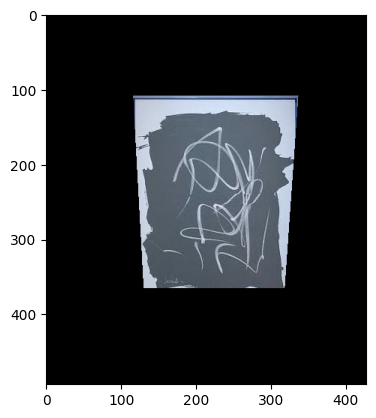

In [46]:
img = cv2.imread("../data/qsd2_w1/00026.jpg", cv2.IMREAD_UNCHANGED)
middle_y = img.shape[0] // 2
shift_y = middle_y // 4

# Get points by whole row/column aware methods
top_point, bottom_point, left_point, right_point = get_borders(img)

#Combine row aware with ray throw to get a corrected bottom side
bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0), threshold=4)
bottom_median= int(np.median(bottom_side[:, 0]))

correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]

top_side = compute_bottom_side(img, (0, 0), (0, 1), (1, 0), threshold=2)
top_median= int(np.median(top_side[:, 0]))

correct_top_values = top_side[(top_side[:,0] >= top_point[0] + 10) & (top_side[:, 0] <= top_median - 10)]
corrected_top_median = int(np.median(correct_top_values[:, 0])) if len(correct_top_values) > 0 else top_point[0]

print(f"Correct bottom: {len(correct_values)}")

border_image = img.copy()

left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
left_median = int(np.median(left_side[:, 1]))
correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]
print(f"Correct left: {len(correct_left_values)}")

right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
right_median = int(np.median(right_side[:, 1]))
correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]

print(f"Correct right: {len(correct_right_values)}")

left_line_func = get_vertical_func(img, (top_point[0], 0), (corrected_median, 0), (0, 1), corrected_left_median, shift_y)
right_line_func = get_vertical_func(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (0, -1), corrected_right_median, shift_y)

y = np.array([left_line_func(x) for x in range(img.shape[0])])

W = img.shape[1]
cols = np.arange(W)
mask_left = cols < y[:, None]

y = np.array([right_line_func(x) for x in range(img.shape[0])])

W = img.shape[1]
cols = np.arange(W)
mask_right = cols > y[:, None]

mask = mask_left | mask_right

border_image[mask] = 0
border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
border_image[range(corrected_top_median), :, :] = 0
#border_image[:, range(img.shape[1] - 1, rt_median, -1), :] = 0

plt.imshow(border_image)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

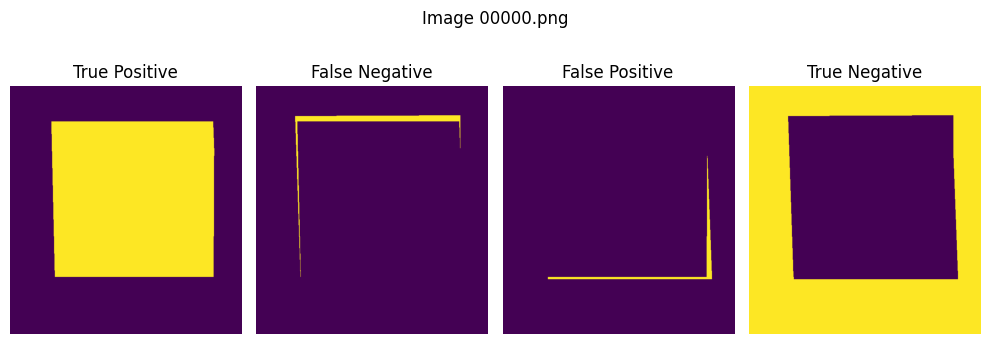

  3%|▎         | 1/30 [00:00<00:24,  1.20it/s]

Precision: 0.9717681172656286
Recall: 0.955960222136123
F_score: 0.9637993551875136


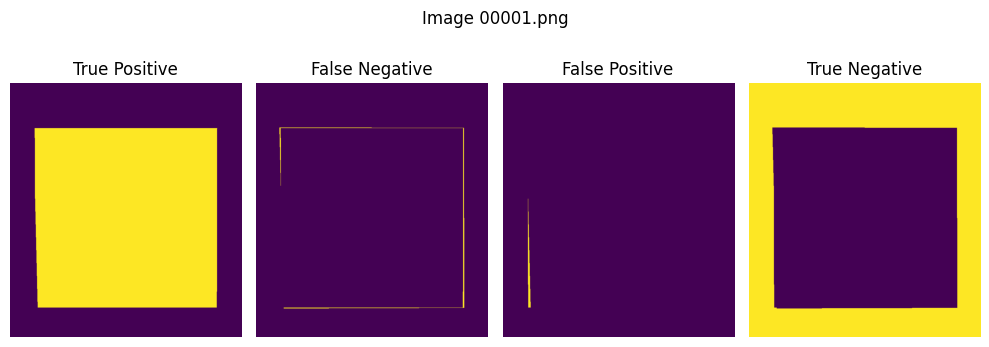

  7%|▋         | 2/30 [00:01<00:27,  1.01it/s]

Precision: 0.9953556347587992
Recall: 0.9866581920418692
F_score: 0.9909878304078769


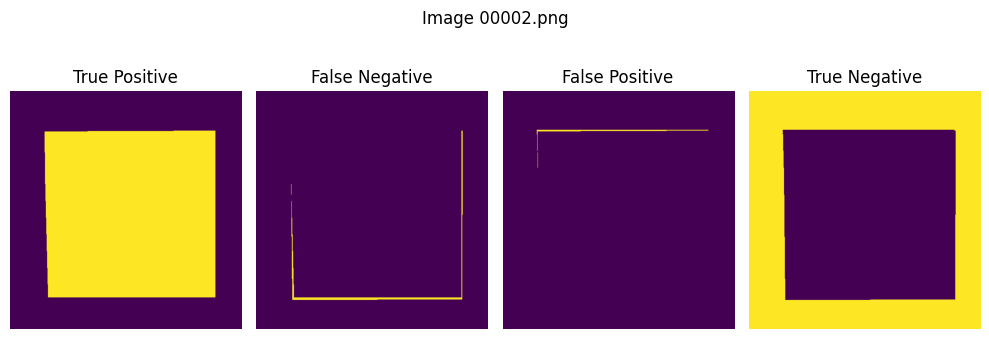

 10%|█         | 3/30 [00:02<00:21,  1.25it/s]

Precision: 0.9917758529034679
Recall: 0.9764477694652258
F_score: 0.9840521253490537


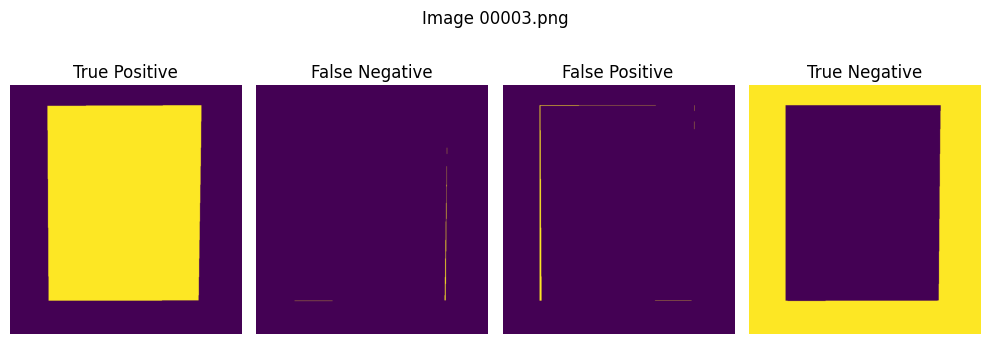

 13%|█▎        | 4/30 [00:03<00:22,  1.14it/s]

Precision: 0.9887776964174328
Recall: 0.9967357963399365
F_score: 0.992740798022099


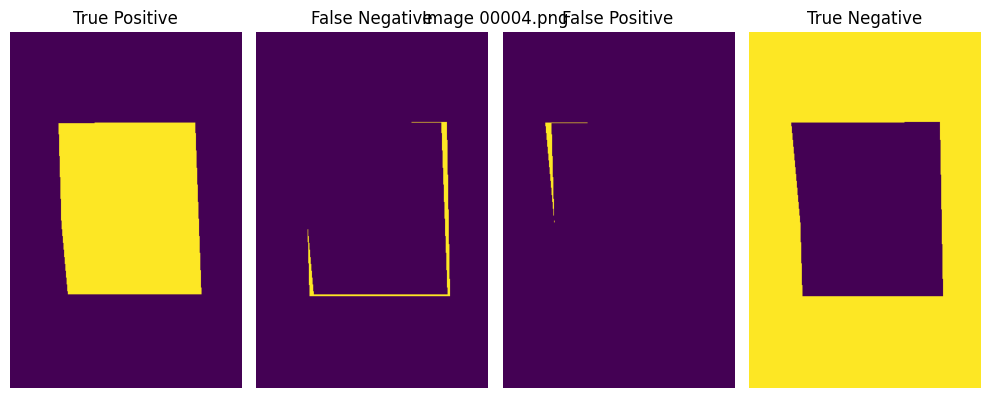

 17%|█▋        | 5/30 [00:04<00:19,  1.30it/s]

Precision: 0.9859440684293389
Recall: 0.9535657661334631
F_score: 0.9694846545477759


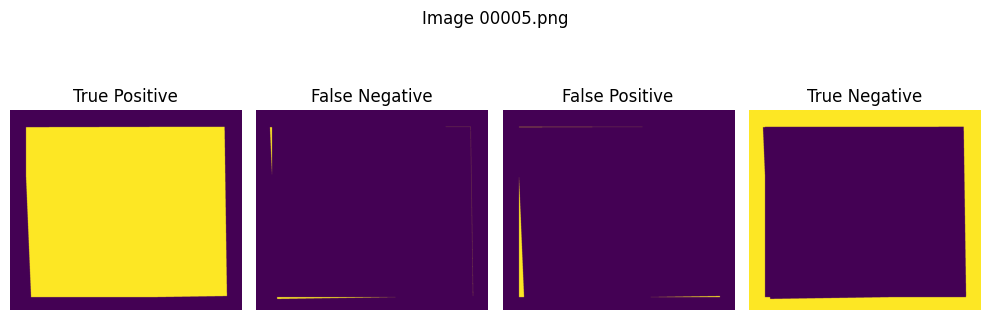

 20%|██        | 6/30 [00:06<00:34,  1.42s/it]

Precision: 0.9890482276458639
Recall: 0.9945908622521568
F_score: 0.9918118014036912


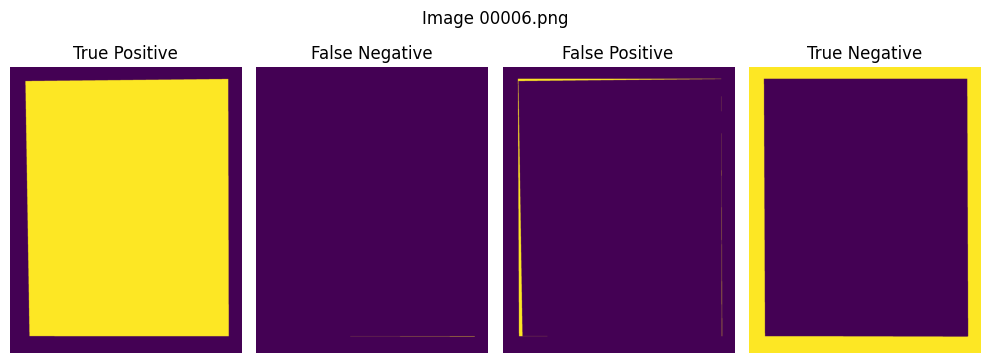

 23%|██▎       | 7/30 [00:10<00:46,  2.04s/it]

Precision: 0.9844056753237829
Recall: 0.9994465381289972
F_score: 0.9918690894868015


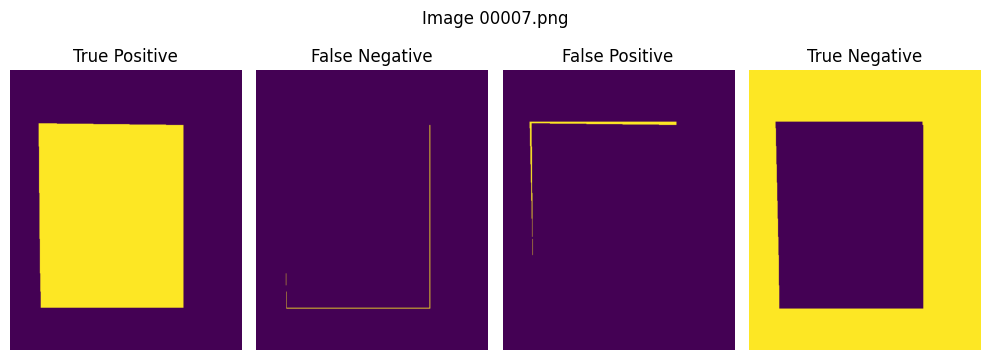

 27%|██▋       | 8/30 [00:10<00:36,  1.65s/it]

Precision: 0.9813196919186113
Recall: 0.989414105511233
F_score: 0.9853502755841133


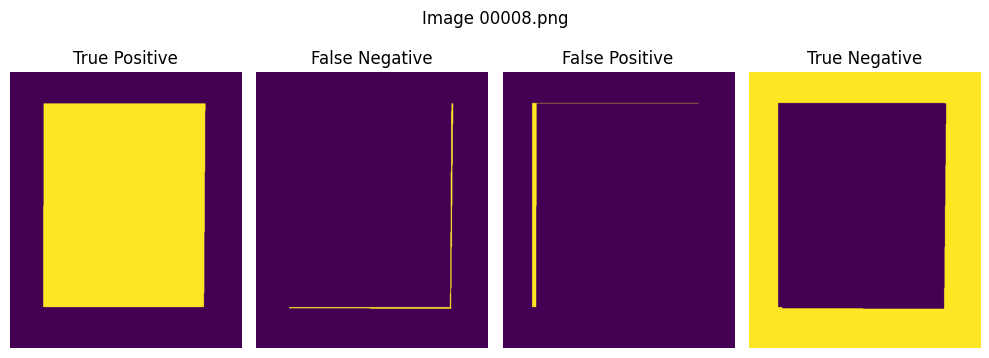

 30%|███       | 9/30 [00:11<00:28,  1.35s/it]

Precision: 0.9723731708263789
Recall: 0.9842643433162749
F_score: 0.9782826236582234


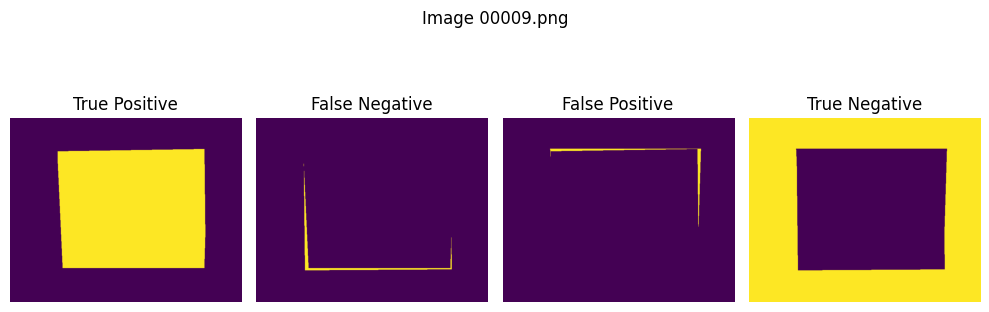

 33%|███▎      | 10/30 [00:12<00:23,  1.17s/it]

Precision: 0.9789159379665459
Recall: 0.9726157609222126
F_score: 0.9757556799373164


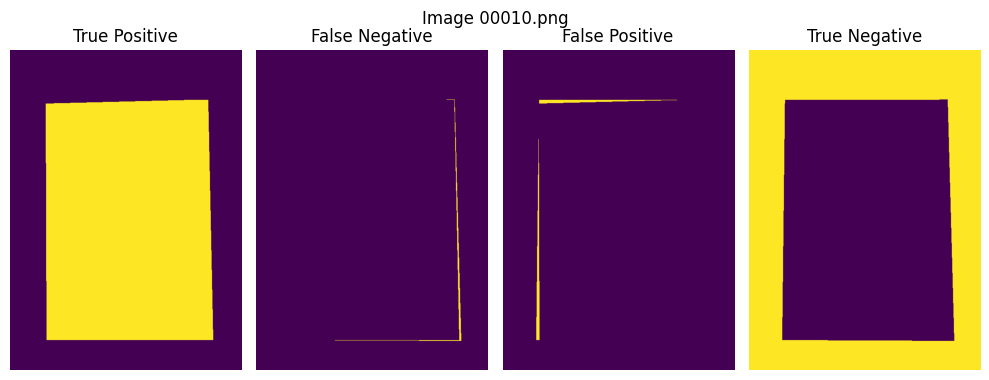

 37%|███▋      | 11/30 [00:13<00:19,  1.03s/it]

Precision: 0.9839278862978064
Recall: 0.9906651158052028
F_score: 0.9872850074775409


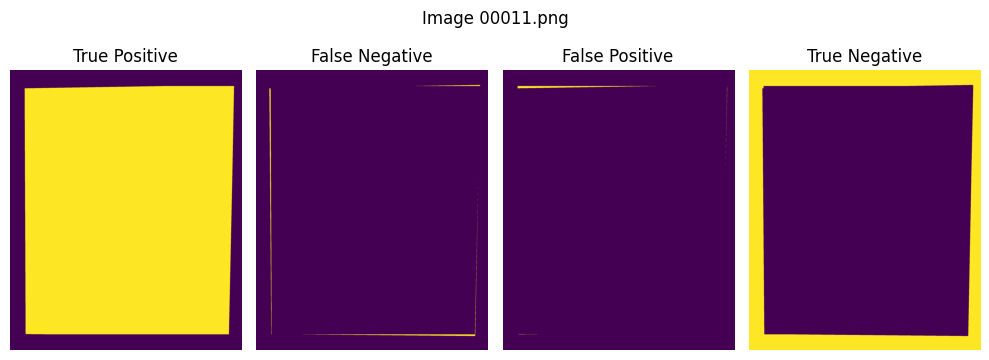

 40%|████      | 12/30 [00:16<00:32,  1.81s/it]

Precision: 0.9966158229347438
Recall: 0.992060028715814
F_score: 0.994332707463285


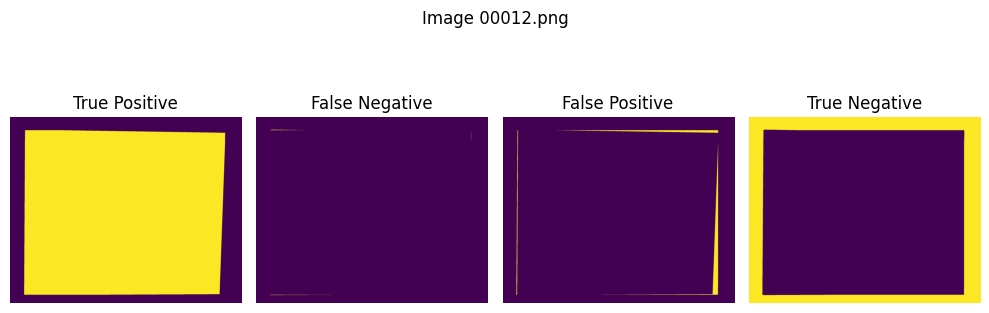

 43%|████▎     | 13/30 [00:19<00:35,  2.09s/it]

Precision: 0.9766776600313318
Recall: 0.9992705261223976
F_score: 0.9878449303787267


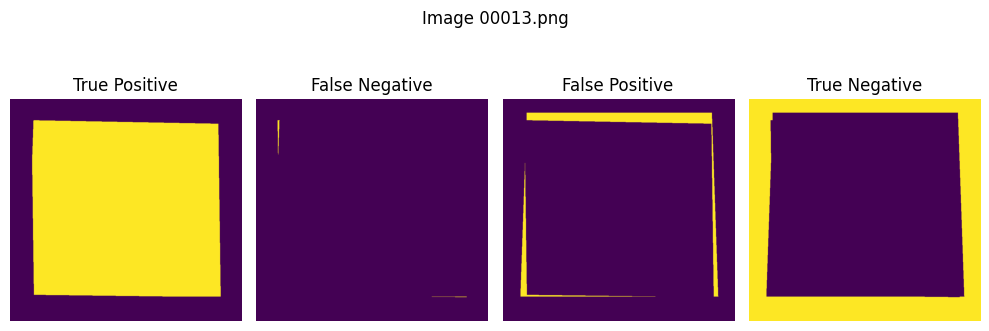

 47%|████▋     | 14/30 [00:20<00:27,  1.70s/it]

Precision: 0.921328003115437
Recall: 0.9984083443394629
F_score: 0.9583207271181567


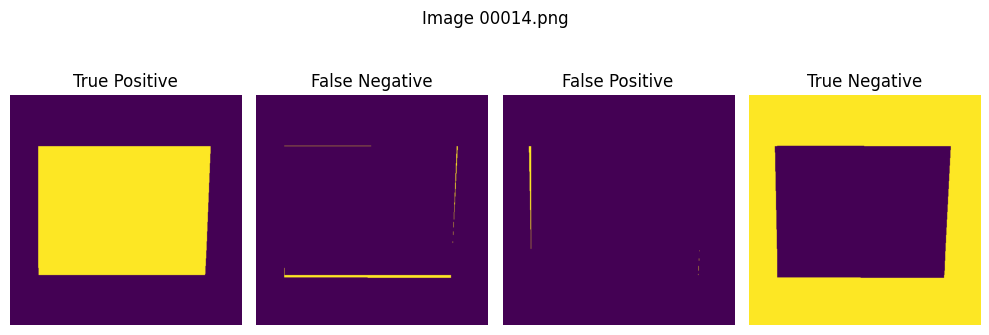

 50%|█████     | 15/30 [00:20<00:20,  1.38s/it]

Precision: 0.9939481082473121
Recall: 0.9766220803958642
F_score: 0.9852089256971871


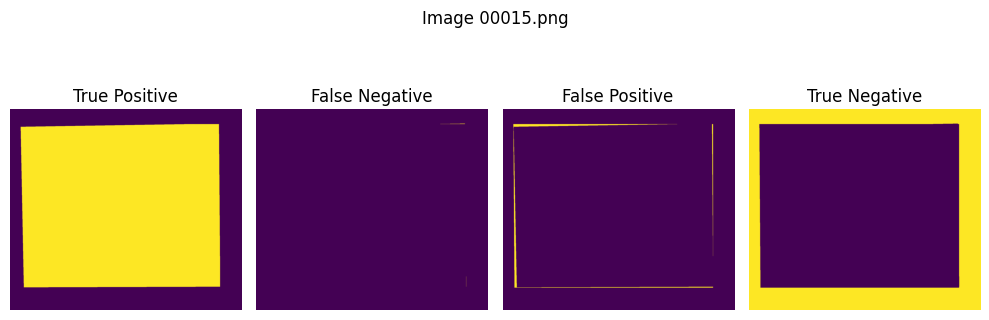

 53%|█████▎    | 16/30 [00:22<00:19,  1.40s/it]

Precision: 0.9803614348923506
Recall: 0.9997266142953148
F_score: 0.9899493292661521


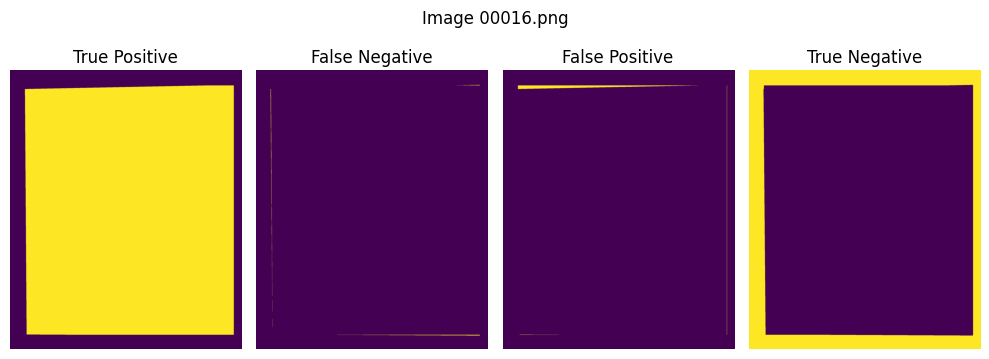

 57%|█████▋    | 17/30 [00:25<00:24,  1.85s/it]

Precision: 0.9922640871454736
Recall: 0.997621617475619
F_score: 0.9949356400542916


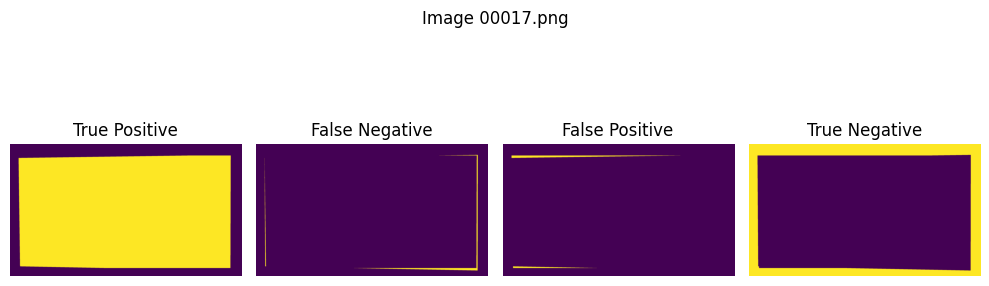

 60%|██████    | 18/30 [00:28<00:27,  2.27s/it]

Precision: 0.9880635846239403
Recall: 0.9857164578952209
F_score: 0.9868886257130247


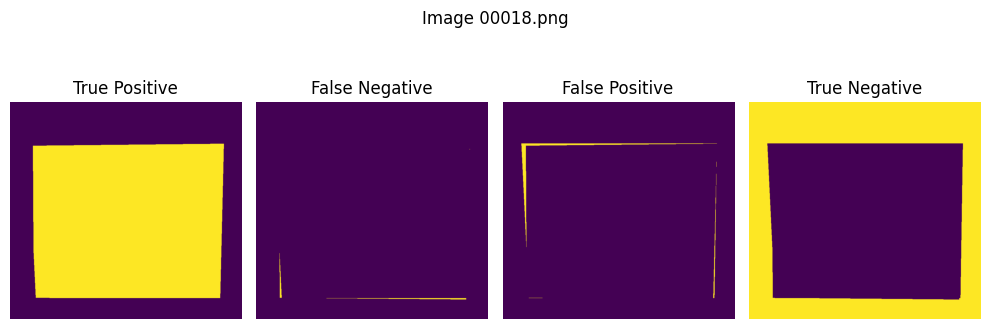

 63%|██████▎   | 19/30 [00:29<00:20,  1.82s/it]

Precision: 0.9802789387859595
Recall: 0.9945371389853477
F_score: 0.987356566681428


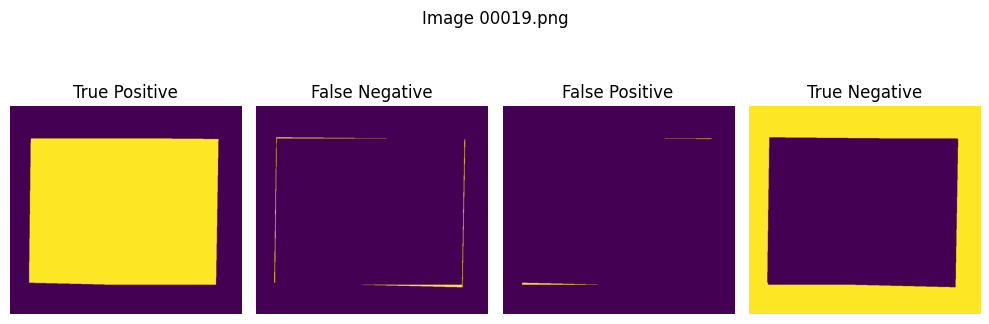

 67%|██████▋   | 20/30 [00:30<00:15,  1.53s/it]

Precision: 0.9964184038938378
Recall: 0.9858894842363204
F_score: 0.9911259821753499


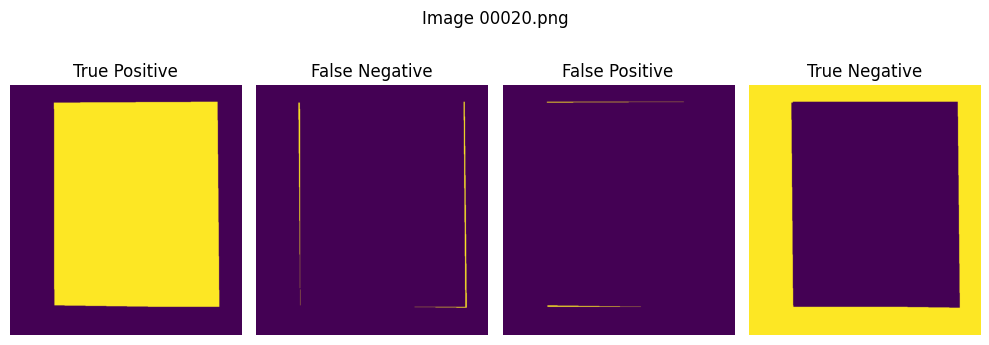

 70%|███████   | 21/30 [00:31<00:12,  1.36s/it]

Precision: 0.9956500083846214
Recall: 0.9860276621058893
F_score: 0.9908154738406014


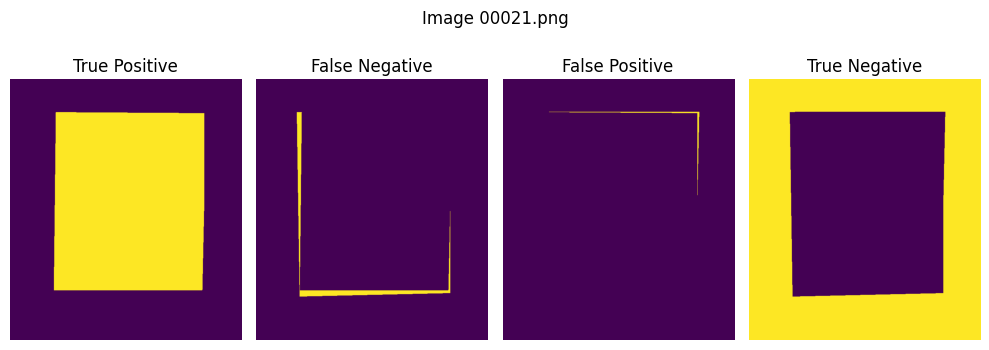

 73%|███████▎  | 22/30 [00:31<00:09,  1.24s/it]

Precision: 0.9916713532042527
Recall: 0.9553910059599061
F_score: 0.9731931668856768


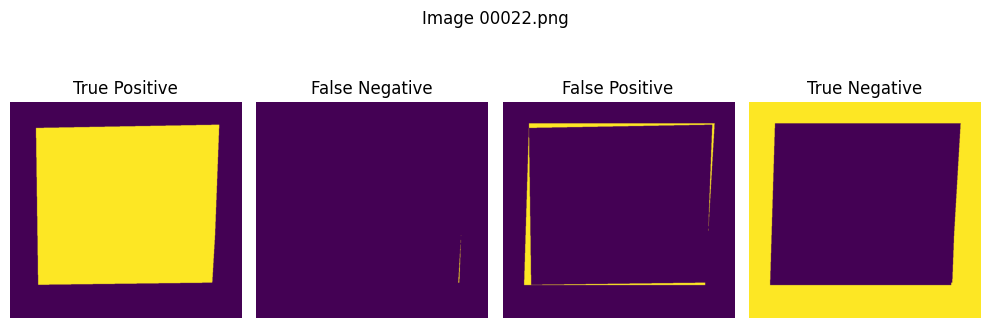

 77%|███████▋  | 23/30 [00:32<00:07,  1.14s/it]

Precision: 0.9503412712693714
Recall: 0.9991396177518627
F_score: 0.9741296976618442


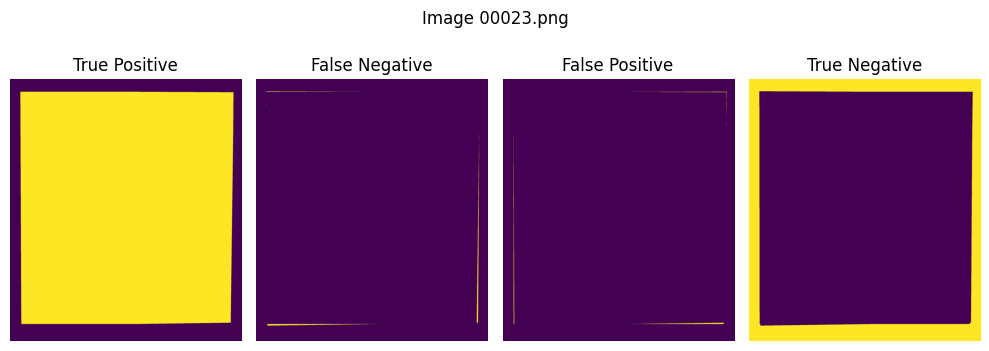

 80%|████████  | 24/30 [00:36<00:10,  1.75s/it]

Precision: 0.9966763088083213
Recall: 0.9951058191161264
F_score: 0.9958904448086932


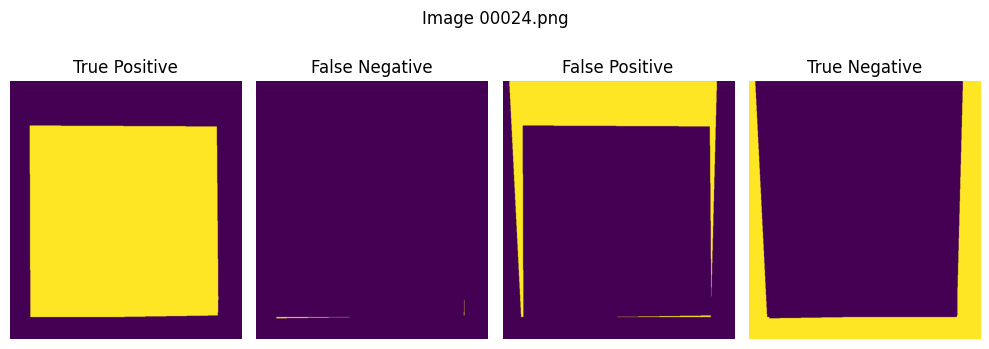

 83%|████████▎ | 25/30 [00:36<00:07,  1.45s/it]

Precision: 0.762242834107898
Recall: 0.9983432802485646
F_score: 0.8644621301326101


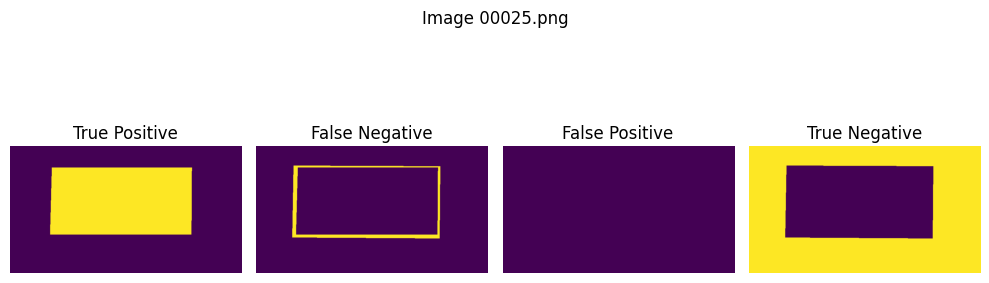

 87%|████████▋ | 26/30 [00:37<00:04,  1.20s/it]

Precision: 1.0
Recall: 0.8895239429852658
F_score: 0.9415323328265464


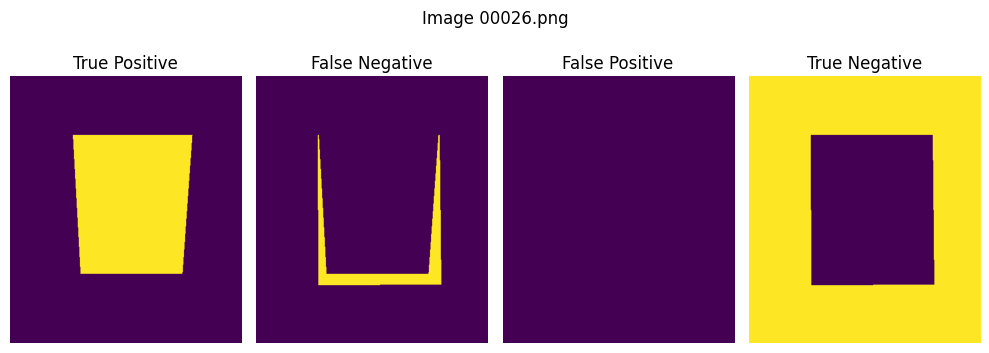

 90%|█████████ | 27/30 [00:38<00:03,  1.02s/it]

Precision: 1.0
Recall: 0.8371043609981663
F_score: 0.9113302202857292


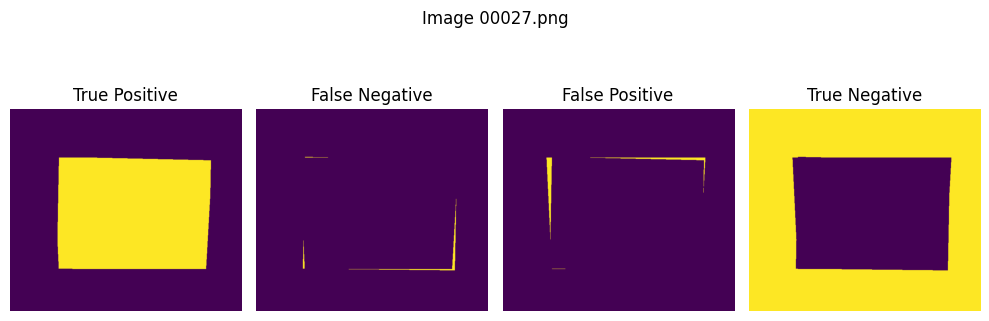

 93%|█████████▎| 28/30 [00:38<00:01,  1.06it/s]

Precision: 0.9752381349396586
Recall: 0.9866032205689063
F_score: 0.9808877583821329


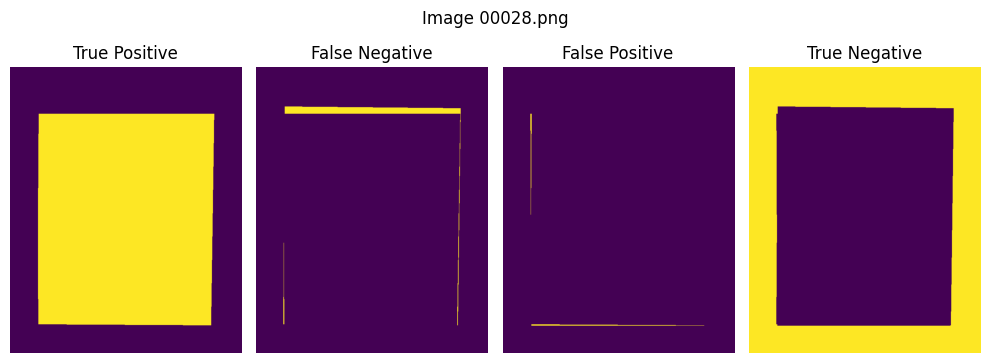

 97%|█████████▋| 29/30 [00:39<00:00,  1.13it/s]

Precision: 0.9939864566228018
Recall: 0.9660642280654447
F_score: 0.9798264569648574


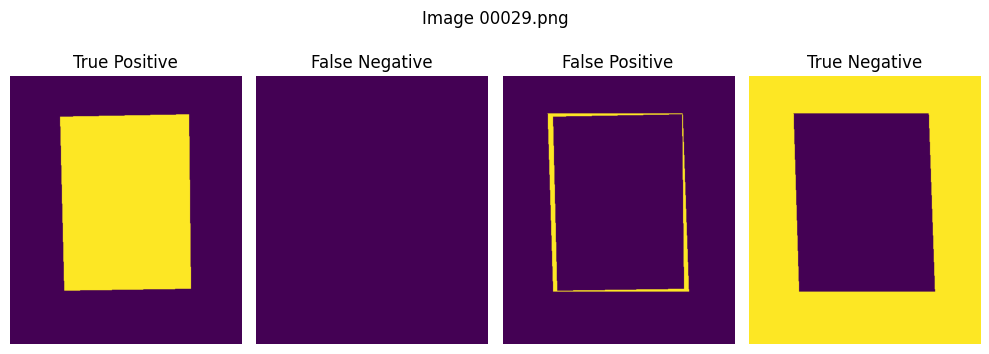

100%|██████████| 30/30 [00:40<00:00,  1.34s/it]

Precision: 0.9232636938520358
Recall: 1.0
F_score: 0.9601009958263852
Average F_score : 0.9753183784408227
Average Precision : 0.9746212688204338
Average Recall : 0.9781173300771397


In [45]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w1/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    correct_img = cv2.imread(f"../data/qsd2_w1/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    middle_y = img.shape[0] // 2
    shift_y = middle_y // 4

    # Get points by whole row/column aware methods
    top_point, bottom_point, left_point, right_point = get_borders(img)

    #Combine row aware with ray throw to get a corrected bottom side
    bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0), threshold=4)
    bottom_median= int(np.median(bottom_side[:, 0]))

    correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
    corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]
    
    top_side = compute_bottom_side(img, (0, 0), (0, 1), (1, 0), threshold=2)
    top_median= int(np.median(top_side[:, 0]))

    correct_top_values = top_side[(top_side[:,0] >= top_point[0] + 10) & (top_side[:, 0] <= top_median - 10)]
    corrected_top_median = int(np.median(correct_top_values[:, 0])) if len(correct_top_values) > 0 else top_point[0]

    border_image = img.copy()

    left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
    left_median = int(np.median(left_side[:, 1]))
    correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
    corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]

    right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
    right_median = int(np.median(right_side[:, 1]))
    correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
    corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]
    
    left_line_func = get_vertical_func(img, (top_point[0], 0), (corrected_median, 0), (0, 1), corrected_left_median, shift_y)
    right_line_func = get_vertical_func(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (0, -1), corrected_right_median, shift_y)

    y_left = np.array([left_line_func(x) for x in range(img.shape[0])])

    W = img.shape[1]
    cols = np.arange(W)
    mask_left = cols < y_left[:, None]

    y_right = np.array([right_line_func(x) for x in range(img.shape[0])])

    W = img.shape[1]
    mask_right = cols > y_right[:, None]

    mask = mask_left | mask_right

    border_image[mask] = 0
    mask_middle = (cols >= y_left[:, None]) & (cols <= y_right[:, None])
    border_image[mask_middle] = 255
    border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
    border_image[range(corrected_top_median), :, :] = 0
    
    result = border_image[:, :, 0]
    
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")
    